# Финальный мёрж новостей и котировок и всего всего что мы напарсили и наапишили

Какие датасеты юзаем:

- mega_dataset.csv - котировки MOEX по 9 тикерам за 2018-2025 (наша апи часть)
- all_data.csv - новости РБК с сентиментом (скрапинг часть команды)
- vse_dividends.csv - дивидендные выплаты по всем 9 компаниям
- vse_indices.csv - входит ли тикер в IMOEX

Что мы делаем тут - к каждой новости мы подтягиваем цену акции в день публикации и цену на следующий торговый день. Разница между ними и есть наш таргет: насколько изменилась цена акции после выхода той или иной новости.

## Шаг 1 - Загружаем все файлы

In [19]:
import pandas as pd
#загружаем все файлы
df_birja = pd.read_csv('mega_dataset.csv')
df_novosti = pd.read_csv('all_data.csv')
df_dividentiki = pd.read_csv('vse_dividends.csv')
df_idishki = pd.read_csv('vse_indices.csv')
print(f'Из биржи {len(df_birja)} строк')
print(f'Из новостей {len(df_novosti)} строк')
print(f'Колво дивидентов {len(df_dividentiki)} строк')
print(f'Колво индексов {len(df_idishki)} строк')

Из биржи 18648 строк
Из новостей 14178 строк
Колво дивидентов 91 строк
Колво индексов 180 строк


## Шаг 2 - Чистим биржевую таблицу

Из большой биржевой таблицы нам не нужно все подряд а нужны только четыре колонки: тикер, дата, цена закрытия и объем торгов.

In [20]:
#оставляем только нужное: тикер, дата, цена закрытия
df_kolonkinuzni = df_birja[['ticker', 'begin', 'close', 'volume']].copy()
#приводим дату к формату datetime и берём только дату без времени
df_kolonkinuzni['date'] = pd.to_datetime(df_kolonkinuzni['begin']).dt.date
df_kolonkinuzni = df_kolonkinuzni.drop(columns=['begin'])
#сортируем по тикеру и дате
df_kolonkinuzni = df_kolonkinuzni.sort_values(['ticker', 'date']).reset_index(drop=True)
df_kolonkinuzni

,ticker,close,volume,date
0,ALRS,75.81,3908500,2018-01-03
1,ALRS,77.00,12833400,2018-01-04
2,ALRS,76.90,5883800,2018-01-05
3,ALRS,76.79,13198500,2018-01-09
4,ALRS,76.70,10944800,2018-01-10
...,...,...,...,...
18643,VTBR,72.92,72258291,2025-12-26
18644,VTBR,72.95,8640898,2025-12-27
18645,VTBR,72.92,6997767,2025-12-28
18646,VTBR,72.17,91335409,2025-12-29


По итогу получили таблицу только из четырех колонок: ticker, date, close, volume.

Close - это финальная цена торгового дня. Цена открытия следующего дня зависит от ночных новостей и не отражает реакцию именно на нашу статью.

Сортируем потому что если строки не отсортированы, следующая строка может оказаться другим годом или другим тикером и будет не hooray...

## Шаг 3 - Чистим новости

Чистим таблицу новостей: убираем строки без даты и тикер AFLT для которого у нас нет котировок, потому что мы мы собрали 10к строк и без него, а апишить дальше было лень 🙄

In [21]:
#убираем новости без даты
df_novosti = df_novosti.dropna(subset=['published_at']).copy()
print(f'Новостей после удаления строк без даты {len(df_novosti)}')
#убираем AFLT, почему мы это делаем смотрите выше
df_novosti = df_novosti[df_novosti['ticker'] != 'AFLT'].copy()
print(f'Новостей после удаления AFLT {len(df_novosti)}')
#приводим дату к datetime
#format mixed потому что в файле два разных формата
#одни даты выглядят как 2025-03-07 11:06:23
#другие как 2025-11-18T12:53:08.000 с Тешкой посередине
df_novosti['published_at'] = pd.to_datetime(df_novosti['published_at'], format='mixed')
#берём только дату без времени
df_novosti['date'] = df_novosti['published_at'].dt.date
df_novosti[['ticker', 'published_at', 'date', 'title']]

Новостей после удаления строк без даты 12368
Новостей после удаления AFLT 10938


,ticker,published_at,date,title
1,MTSS,2025-06-17 16:16:19,2025-06-17,Структурная перезагрузка
2,MTSS,2025-03-07 11:06:23,2025-03-07,"Каждый четвертый мужчина уверен, что не поздра..."
3,MTSS,2025-04-08 07:01:07,2025-04-08,Краха не избежать. Почему массовые увольнения ...
4,MTSS,2025-03-08 09:00:22,2025-03-08,Брокеры составили портрет среднестатистической...
5,MTSS,2025-07-25 16:05:18,2025-07-25,В торговых центрах Петербурга стали закрыватьс...
...,...,...,...,...
12677,VTBR,2025-10-13 16:02:53,2025-10-13,Цена на серебро впервые в истории превысила $5...
12678,VTBR,2026-02-11 18:53:35,2026-02-11,В России установлен январский рекорд продаж но...
12679,VTBR,2025-08-25 09:07:41,2025-08-25,"Коррекция акций и ОФЗ, дивиденды «Газпром нефт..."
12680,VTBR,2025-08-12 11:48:12,2025-08-12,Врачи спасли подростка с разрывом печени после...


Почистили

## Шаг 4 - Сдвигаем даты к будням

Биржа не работает в субботу и воскресенье. Если новость вышла в выходной - в этот день нет данных из биржи.
Поэтому мы сдвигаем дату новости к следующему торговому дню - понедельнику.

In [22]:
#функция сдвига выходных к понедельнику
def sdvigtobudni(date):
    den = pd.Timestamp(date)
    if den.weekday() == 5: #суббота пятая-сдвигаем на 2 дня вперёд
        return (den + pd.Timedelta(days = 2)).date()
    elif den.weekday() == 6:  #воскресенье шестой- сдвигаем на 1 день вперёд
        return (den + pd.Timedelta(days = 1)).date()
    return den.date()

df_novosti['date_trading'] = df_novosti['date'].apply(sdvigtobudni)
#смотрим сколько новостей сдвинулось
novostivvihodni = (df_novosti['date_trading'] != df_novosti['date']).sum()
print(f'Новости которые раньше были в выходной, но сдвинулись на понедельник {novostivvihodni}')
df_novosti[df_novosti['date_trading'] != df_novosti['date']][['ticker', 'date', 'date_trading']]

Новости которые раньше были в выходной, но сдвинулись на понедельник 1038


,ticker,date,date_trading
4,MTSS,2025-03-08,2025-03-10
31,MTSS,2026-01-17,2026-01-19
62,MTSS,2025-09-20,2025-09-22
78,MTSS,2026-03-08,2026-03-09
112,MTSS,2025-08-31,2025-09-01
...,...,...,...
12613,VTBR,2025-08-23,2025-08-25
12654,VTBR,2025-09-06,2025-09-08
12663,VTBR,2025-09-06,2025-09-08
12675,VTBR,2026-01-11,2026-01-12


Дни недели нумеруются с 0 (понедельник) до 6 (воскресенье), поэтому суббота - 5, воскресенье - 6.

Но если что исходная дата публикации published_at остаётся без изменений.

## Шаг 5 - Мержим цену с новостью

In [23]:
#переименовываем колонки для мёржа
df_chenasegodni = df_kolonkinuzni.rename(columns={'date': 'date_trading', 'close': 'current_price'})
#мёрж по тикеру и торговой дате, то есть склеиваем по двум колонкам одновременно и если совпадение и тикера и даты добавляем цену к этой новости но строка все равно остается просто нан будет если не нашлась цена
df_tikplusden = df_novosti.merge(df_chenasegodni, on=['ticker', 'date_trading'], how='left')
print(f'Новости с ценой {df_tikplusden["current_price"].notna().sum()}')
print(f'Новости без цены {df_tikplusden["current_price"].isna().sum()}')

Новости с ценой 9268
Новости без цены 1670


Биржа может не работать не только в выходные, но и в праздники. Выходные мы сдвинули, но праздники не обрабатывали и еще часть новостей может быть за пределами нашего диапазона 2018 - 2025 по апи, но почистим их потом уже

## Шаг 6 - Смотрим цену след. дня

Для расчёта таргета нам нужна цена на след. день. Используем shift - сдвиг на одну строку вперёд по отсортированной таблице. Это нам даст следующий торговый день.

In [24]:
#делаем для каждого тикера отдельно потому что shift может перепрыгнуть с одной компании на другую
sleddaychena =[]
for ticker in df_kolonkinuzni['ticker'].unique():
    df_tikerplussortingpodate = df_kolonkinuzni[df_kolonkinuzni['ticker'] == ticker].sort_values('date').reset_index(drop=True)
    #shift(-1) сдвигает все цены на одну строку назад
    df_tikerplussortingpodate['price_next'] = df_tikerplussortingpodate['close'].shift(-1)
    sleddaychena.append(df_tikerplussortingpodate[['ticker', 'date', 'price_next']])
df_sleddenis = pd.concat(sleddaychena, ignore_index=True)
df_sleddenis = df_sleddenis.rename(columns={'date': 'date_trading'})
#подтягиваем в основную таблицу
df_tikplusden = df_tikplusden.merge(df_sleddenis, on=['ticker', 'date_trading'], how='left')
print(f'Новостей с ценой следующего дня {df_tikplusden["price_next"].notna().sum()}')

Новостей с ценой следующего дня 9243


Делаем цикл по тикерам а не сразу shiftим по всей таблице, потому что если сделать shift по всей таблице, последняя строка SBER и первая строка VTBR окажутся рядом и shift возьмёт цену другой компании. Цикл гарантирует что shift работает только внутри одного тикера и не возьмет никакую другую цену.

## Шаг 7 - Считаем таргет

Таргет - изменение цены в % от торгового дня новости до следующего торгового дня.

Положительный таргет = цена выросла после новости. Отрицательный = упала.

In [25]:
#формула: (цена_завтра - цена_сегодня) / цена_сегодня * 100
df_tikplusden['target'] = ((df_tikplusden['price_next'] - df_tikplusden['current_price']) / df_tikplusden['current_price'] * 100)
print(f'Строк с таргетом {df_tikplusden["target"].notna().sum()}')
print(f'Средний таргет {df_tikplusden["target"].mean()}%')
print(f'Max таргет {df_tikplusden["target"].max()}%')
print(f'Min таргет {df_tikplusden["target"].min()}%')

Строк с таргетом 9243
Средний таргет -0.03720363839940232%
Max таргет 17.16748768472906%
Min таргет -36.30883375840483%


Рынок в среднем не растёт и не падает после каждой отдельной новости судя по среднему таргету, это значит что все слава богу правильно.

## Шаг 8 - День выплаты дивидента

Когда компания выплачивает дивиденды, цена акции падает примерно на размер дивиденда и это не реакция на новость. Если не пометить такие дни, модель может решить что негативные новости вызывают падение и будет просто каша (когда на самом деле это просто выплата дивидента)

In [26]:
#приводим дату дивидендов к нужному типу
df_dividentiki['registryclosedate'] = pd.to_datetime(df_dividentiki['registryclosedate']).dt.date
#присоединяем дивиденды по тикеру и дате
df_tikplusden = df_tikplusden.merge(
    df_dividentiki[['ticker', 'registryclosedate']],
    left_on=['ticker', 'date_trading'],
    right_on=['ticker', 'registryclosedate'],
    how='left')
#если совпадение нашлось - дивидендный день, если нет - 0
df_tikplusden['is_dividend_day'] = df_tikplusden['registryclosedate'].notna().astype(int)
#убираем лишнюю колонку которую добавил merge
df_tikplusden = df_tikplusden.drop(columns=['registryclosedate'])
print(f'Дивидендных дней {df_tikplusden["is_dividend_day"].sum()}')

Дивидендных дней 45


Потом в EDA можно будет отдельно посмотреть насколько сильно падает цена в дивидендные дни по сравнению с обычными.

## Шаг 9 - Вхождение в индекс

Бумаги которые входят в IMOEX (главный индекс Московской биржи) отслеживаются индексными фондами - поэтому они реагируют на новости быстрее и сильнее ну в общем активнее.

In [27]:
#находим тикеры которые входят в IMOEX
imoex_tickers = set(df_idishki[df_idishki['SECID'] == 'IMOEX']['ticker'].unique())
#добавляем флаг: 1 если тикер в IMOEX, 0 если нет
df_tikplusden['in_imoex'] = df_tikplusden['ticker'].isin(imoex_tickers).astype(int)
print(f'Тикеры в IMOEX {imoex_tickers}')
print(f'Новостей по индексным бумагам {df_tikplusden["in_imoex"].sum()}')

Тикеры в IMOEX {'GAZP', 'MGNT', 'SBER', 'LKOH', 'ALRS', 'GMKN', 'ROSN', 'MTSS', 'VTBR'}
Новостей по индексным бумагам 10938


Все 9 наших тикеров входят в IMOEX, что подтверждает что мы выбрали крупнейшие и самые ликвидные компании рынка.

## Шаг 10 - Финальный датасет

In [28]:
#собираем только нужные колонки
df_finalochka = df_tikplusden[['ticker', 'published_at', 'date_trading', 'title', 'text', 'category', 'url', 'sentiment_positive', 'sentiment_negative',
                               'sentiment_neutral', 'current_price', 'price_next', 'target', 'is_dividend_day', 'in_imoex', 'volume']].copy()
#убираем строки без таргета (праздники, последний день периода)
df_finalochka = df_finalochka.dropna(subset=['target']).reset_index(drop=True)
#сохраняем
df_finalochka.to_csv('finalochka_dataseta_merg.csv', index=False)
print(f'Строк {len(df_finalochka)}')
print(f'Колонок {len(df_finalochka.columns)}')
df_finalochka[['ticker','date_trading','current_price','price_next','target','is_dividend_day']]

Строк 9243
Колонок 16


,ticker,date_trading,current_price,price_next,target,is_dividend_day
0,MTSS,2025-06-17,226.05,228.45,1.061712,0
1,MTSS,2025-03-07,242.00,239.75,-0.929752,0
2,MTSS,2025-04-08,202.10,216.05,6.902524,0
3,MTSS,2025-03-10,239.75,240.80,0.437956,0
4,MTSS,2025-07-25,209.35,209.70,0.167184,0
...,...,...,...,...,...,...
9238,VTBR,2025-09-05,75.50,75.64,0.185430,0
9239,VTBR,2025-11-03,68.66,69.41,1.092339,0
9240,VTBR,2025-10-13,67.98,67.25,-1.073845,0
9241,VTBR,2025-08-25,76.32,76.40,0.104822,0


Датасет ФИНАЛОЧКА готов.

Что в колонках
- ticker - тикер компании
- published_at - точная дата и время публикации новости
- date_trading - торговый день к которому привязана новость (выходные сдвинуты к понедельнику)
- title - заголовок статьи
- text - полный текст статьи
- category - рубрика на РБК
- url - ссылка на статью
- sentiment_positive / negative / neutral - тональность текста
- current_price - цена закрытия в торговый день новости
- price_next - цена закрытия следующего торгового дня
- target - изменение цены в % после новости
- is_dividend_day - 1 если в этот день была выплата дивидендов
- in_imoex - 1 если тикер входит в главный индекс MOEX
- volume - объем торгов

Надо начинать Eda....

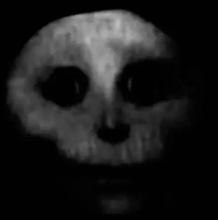